# HarvestStat Data Profiling - Kenya

In [1]:
import glob
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
import numpy as np
import pandas as pd
import geopandas as gpd
from tools import retreive_fdw_data, save_npz, PrintAdminUnits, PlotAdminShapes
from tools import FDW_PD_Sweeper, FDW_PD_AvalTable, FDW_PD_Compiling, FDW_PD_ValidateFnidName
from tools import FDW_PD_CreateAdminLink, FDW_PD_RatioAdminLink, FDW_PD_ConnectAdminLink
from tools import product_name_mapping, FDW_PD_CaliSeasonYear, FDW_PD_MergeCropProductionSystem
from tools_graphic import PlotBarProduction, PlotLinePAY
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
pd.options.mode.chained_assignment = None

In [2]:
# Set loading parameters ------------------------ #
country_name = 'Kenya'
country_iso2 = 'KE'
use_api_data = False
requires_authentication = True
# ----------------------------------------------- #

# Load FEWS NET administrative boundaries ------- #
epsg = 'epsg:32737' # Kenya
fn_shapes = sorted(glob.glob(f"../data/shapefile/fewsnet/{country_iso2}_Admin?_????.shp"))
shape_all = []
for fn in fn_shapes:
    name = fn[-18:-4]
    exec('%s = gpd.read_file("%s").to_crs("%s")' % (name, fn, epsg))
    exec('%s["area"] = %s["geometry"].area/10**6' % (name, name))
    exec('shape_all.append(%s)' % (name))
shape_all = pd.concat(shape_all, axis=0).reset_index(drop=True)
PrintAdminUnits(shape_all)
# ----------------------------------------------- #

# Load FDW data -------------------------------- #
df = retreive_fdw_data(country_name, country_iso2, use_api_data, requires_authentication)
# ----------------------------------------------- #

- FEWS NET admin shapefiles ------------------- #
| year	 | Admin1   | # units   | Admin2   | # units   | Admin3   | # units   |
| 1982	 | KE1982A1 |  8	| KE1982A2	| 41	| nan	|  0	|
| 1989	 | KE1989A1 |  8	| KE1989A2	| 47	| nan	|  0	|
| 2007	 | KE2007A1 | 12	| KE2007A2	| 70	| nan	|  0	|
| 2009	 | KE2009A1 |  8	| KE2009A2	| 47	| nan	|  0	|
| 2013	 | KE2013A1 | 47	| KE2013A2	| 290	| nan	|  0	|
----------------------------------------------- #
Data is loaded from the local file.
../data/crop_raw_data/adm_crop_data_raw_KE.csv is loaded.


In [3]:
# Manual Pre-processing before Sweeping --------- #
# 1. Default setting 
# a) None-type crop production system
df.loc[df['crop_production_system'].isna(), 'crop_production_system'] = 'none'
df.loc[df['crop_production_system'] == '', 'crop_production_system'] = 'none'
# b) None-type population group
df.loc[df['population_group'].isna(), 'population_group'] = 'none'
df.loc[df['population_group'] == '', 'population_group'] = 'none'
# Remove Maize Grain (Fresh) in 2009 and 2012 (see #95)
# https://github.com/HarvestStat/HarvestStat-Africa/issues/95
df = df[df['product'] != 'Maize Grain (Fresh)']
# ----------------------------------------------- #

# FDW Production Data Inspection ---------------- #
df, df_raw = FDW_PD_Sweeper(df, area_priority='Area Planted')
table_dict = FDW_PD_AvalTable(df, shape_all)
# ----------------------------------------------- #

# FEWS NET Shapefile comparison ----------------- #
shape_used = pd.concat([KE_Admin2_1982, KE_Admin2_1989, KE_Admin2_2009, KE_Admin1_2013], axis=0)
PlotAdminShapes(shape_used, label=True)
# ----------------------------------------------- #

- Remove missing records ---------------------- #
Orignial data points: 51,552
Removed 5,350 "Missing Value" points
15,653/17,416 "Area Harvested" points are retained.
15,327/17,121 "Quantity Produced" points are retained.
15,202/16,995 "Yield" points are retained.
20/20 "Area Planted" points are retained.
Current data points: 46,202

- Minor changes are applied ------------------- #

- Basic information --------------------------- #
Data period: 1966 - 2024
44 grain types are found: Amaranth, Arrowroot, Bambara groundnut, Banana (unspecified), Barley (Unspecified), Beans (mixed), Black nightshade, Cabbage (Unspecified), Canola seed, Carrots, Cashew (unshelled), Cassava, Coconut (in shell), Coffee (unspecified), Coriander, Cotton (Unspecified), Cowpea (unspecified), Groundnuts (In Shell), Jute, Kale, Macadamia (unspecified), Maize Grain (White), Millet, Mung bean (unspecified), Onions, Pea (unspecified), Pigeon pea (Unspecified), Pineapple (unspecified), Potato (Irish), Pyrethrum, Rice

- Kenya crop seasonal calendar

<img src="https://fews.net/sites/default/files/styles/large_width_880/public/2023-03/seasonal-calendar-kenya.png?itok=0Wob_hCK" width=900>

- FDW data consists of `KE1982A1`, `KE1982A2`, `KE1989A1`, `KE1989A2`, `KE2013A1`.

| Year | Admin-1 | # units  | Admin-2  | # units |
| :---: | :----:  | :----:   | :----:   | :---:  |
| 1982 | **`KE1982A1`**| 8  | **`KE1982A2`** | 41|
| 1989 | **`KE1989A1`**| 8  | **`KE1989A2`** | 47|
| 2009 | KE2009A1| 8        | KE2009A2 | 47      |
| 2013 | **`KE2013A1`**| 47 | KE2013A2 | 290     |

- Comparison between admin boundaries.

<img src="../figures/KE_admin_shapes.png" width=900>

- In 1989, 6 districts are divided and added.

| 1982-1989 (original) |1989-2013 (changed)|1989-2013 (added)|
| :---:| :---:|:---:|
|Meru (KE1982A25020)    | Meru (KE1989A25017)    | Tharaka Nithi (KE1989A25018)|
|Machakos (KE1982A25019)| Machakos(KE1989A25004) | Makueni       (KE1989A25005)|
|Kericho  (KE1982A25424)| Kericho  (KE1989A25422)| Bomet         (KE1989A25420)|
|Kissi    (KE1982A25319)| Kissi    (KE1989A25314)| Nyamira       (KE1989A25308)|
|Homa Bay (KE1982A25318)| Homa Bay (KE1989A25313)| Migori        (KE1989A25316)|
|Kakamega (KE1982A25512)| Kakamega (KE1989A25511)| Vihiga        (KE1989A25508)|

- In 2013, Admin-2 became Admin-1 (no name changes).
- **`KE2013A1`** is used to represent all admin-level 1 crop data.
- Kenya has three crop seasons: `Annual harvest`, `Long rains harvest`, `Short rains harvest`.
- Kenya has a single crop production system: `None`.

In [4]:
# Define the latest shapefile ------------------- #
latest_level = 1
shape_latest = KE_Admin1_2013.copy().to_crs('epsg:4326')
# ----------------------------------------------- #

# Validation of FNIDs and Names ----------------- #
df = FDW_PD_ValidateFnidName(df, shape_used, shape_latest)
df['season_name'] = df['season_name'].replace({'Annual harvest':'Annual', 'Long rains harvest':'Long', 'Short rains harvest':'Short'})
# ----------------------------------------------- #

# FDW Production Data Compiling ----------------- #
area, prod = FDW_PD_Compiling(df, shape_used)
area_all, prod_all = area.copy(), prod.copy()
mdx_pss = area.columns.droplevel([0,1]).unique()
# ----------------------------------------------- #

KE1982A25318:	"South Nyanza" (FDW) is changed to "Homa Bay" (shapefile).


In [5]:
# Fix for Kenya annual data gap (Issue #94)
# https://github.com/HarvestStat/HarvestStat-Africa/issues/94
#
# KE2007A2 shapefile contains 70 admin_2 units, whereas the underlying data
# and other boundary versions (KE1989A2, KE2009A2, KE2013A1) consistently
# use ~47 units. This mismatch leads to failed FNID linkage.

# Harmonize admin_2 names in KE2007A2 to match KE2009A2 (manually verified)
rename_admin2_2007_to_2009 = {
    "Meru Central": "Meru",
    "Tharaka": "Tharaka - Nithi",
    "Central Kisii": "Kisii",
    "Marakwet": "Elgeyo-Marakwet"
}

mask_2007 = df['fnid'].str.contains('2007A2', na=False)

df.loc[mask_2007, 'admin_2'] = (
    df.loc[mask_2007, 'admin_2']
    .replace(rename_admin2_2007_to_2009)
)

# Map KE2007A2 FNIDs to KE2009A2 FNIDs based on admin_2 names
fnid_mapping_2007_to_2009 = {}

for fnid_2007 in df.loc[mask_2007, 'fnid'].unique():
    admin_2_2007 = df.loc[df['fnid'] == fnid_2007, 'admin_2'].iloc[0]

    fnid_2009 = df.loc[
        df['fnid'].str.contains('2009A2', na=False) &
        (df['admin_2'] == admin_2_2007),
        'fnid'
    ]

    if not fnid_2009.empty:
        fnid_mapping_2007_to_2009[fnid_2007] = fnid_2009.iloc[0]

# Reverse mapping (KE2009A2 → KE2007A2)
fnid_mapping_2009_to_2007 = {
    v: k for k, v in fnid_mapping_2007_to_2009.items()
}

# Create KE2007A2 shapefile using KE2009A2 geometry
KE_Admin2_2007 = KE_Admin2_2009.copy()
KE_Admin2_2007 = KE_Admin2_2007.replace({'FNID': fnid_mapping_2009_to_2007})

# Validate consistency between data and reconstructed shapefile
df = FDW_PD_ValidateFnidName(df, KE_Admin2_2007, KE_Admin2_2007)

In [6]:
# Link admin boundaries ------------------------- #
link_1982, over_1982 = FDW_PD_CreateAdminLink(KE_Admin2_1982, KE_Admin1_2013, 'ADMIN2', 'ADMIN1', prod, epsg)
assert all(np.unique([v['method'] for k,v in link_1982.items()]) == 'PBR')
link_1989, over_1989 = FDW_PD_CreateAdminLink(KE_Admin2_1989, KE_Admin1_2013, 'ADMIN2', 'ADMIN1', prod, epsg)
assert all(np.unique([v['method'] for k,v in link_1989.items()]) == 'PBR')
link_2007, over_2007 = FDW_PD_CreateAdminLink(KE_Admin2_2007, KE_Admin1_2013, 'ADMIN2', 'ADMIN1', prod, epsg)
assert all(np.unique([v['method'] for k,v in link_2007.items()]) == 'PBR')
link_2009, over_2009 = FDW_PD_CreateAdminLink(KE_Admin2_2009, KE_Admin1_2013, 'ADMIN2', 'ADMIN1', prod, epsg)
assert all(np.unique([v['method'] for k,v in link_2009.items()]) == 'PBR')

# Crop specific ratios
link_ratio_1982 = FDW_PD_RatioAdminLink(link_1982, prod, over_1982, mdx_pss)
link_ratio_1989 = FDW_PD_RatioAdminLink(link_1989, prod, over_1989, mdx_pss)
link_ratio_2007 = FDW_PD_RatioAdminLink(link_2007, prod, over_2007, mdx_pss)
link_ratio_2009 = FDW_PD_RatioAdminLink(link_2009, prod, over_2009, mdx_pss)
# Merge link_ratio
assert link_ratio_1982.keys() == link_ratio_1989.keys() == link_ratio_2007.keys() == link_ratio_2009.keys()
link_merged = [link_ratio_1982, link_ratio_1989, link_ratio_2007, link_ratio_2009]
fnids_new = list(link_merged[0].keys())
link_ratio = dict()
for fnid in fnids_new:
    container = []
    for link in link_merged:
        container.append(link[fnid])
    link_ratio[fnid] = pd.concat(container, axis=1)
# Add current unit to link_ratio
for fnid_new in link_ratio.keys():
    link_ratio[fnid_new][fnid_new] = 1.0
    link_ratio[fnid_new] = link_ratio[fnid_new].sort_index(axis=1, ascending=False)
# Connect data with AdminLink
area_new, prod_new = FDW_PD_ConnectAdminLink(link_ratio, area, prod, validation=False)
# ----------------------------------------------- #

In [7]:
# Manual correction ----------------------------- #
crop_new = prod_new/area_new
# - Remove "Short" season yield over 4 mt/ha
rdx = crop_new.loc[:,pd.IndexSlice[:,:,'Maize Grain (White)','Short']] > 4
crop_new[rdx] = np.nan
# prod_new[rdx] = np.nan
# ----------------------------------------------- #

# Complete long format DataFrame ---------------- #
df_area = area_new.T.stack().rename('value').reset_index()
df_area['indicator'] = 'area'
df_prod = prod_new.T.stack().rename('value').reset_index()
df_prod['indicator'] = 'production'
df_yield = crop_new.T.stack().rename('value').reset_index()
df_yield['indicator'] = 'yield'
stack = pd.concat([df_area, df_prod, df_yield], axis=0)
# Add "planting year"
cols = ['season_name','product','crop_production_system','planting_month','harvest_year','harvest_month','planting_year']
season_table = df[cols].drop_duplicates()
stack = stack.merge(season_table, on=cols[:-1])
# Add country and admin names
stack = stack.merge(df[['fnid','country','country_code','admin_1','admin_2']].drop_duplicates(), on='fnid', how='inner')
names = [
    'fnid','country','country_code','admin_1','admin_2','name',
    'product','season_name','planting_year','planting_month','harvest_year','harvest_month',
    'crop_production_system','indicator','value'
]
stack = stack[names]
# ----------------------------------------------- #

# Final Processing ------------------------------ #
# Product name mapping
stack = product_name_mapping(stack, list_except=None)
# Calibration of crop calendar using External Season Calendar (ESC)
esc = pd.read_csv('../data/crop_calendar/external_season_calendar.csv')
stack, link_ratio = FDW_PD_CaliSeasonYear(stack, esc, link_ratio=None)
# None admin names
stack.loc[stack['admin_1'].isna(), 'admin_1'] = 'none'
stack.loc[stack['admin_2'].isna(), 'admin_2'] = 'none'
# ----------------------------------------------- #

All [country, season_name] are in the external season calendar.


In [8]:
# Save data
fn_out = '../data/crop/adm_crop_production_KE.csv'
stack.to_csv(fn_out); print(f'{fn_out} is saved.')
save_npz('../data/crop/adm_crop_production_KE_ratio.npz', link_ratio)

../data/crop/adm_crop_production_KE.csv is saved.
../data/crop/adm_crop_production_KE_ratio.npz is saved.


# Visualization of production data

/Users/dlee/harveststat-africa/notebook/tools_graphic.py:135: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  axes[1].grid(which='minor', axis='x', linestyle='-', color='black', visible=False)


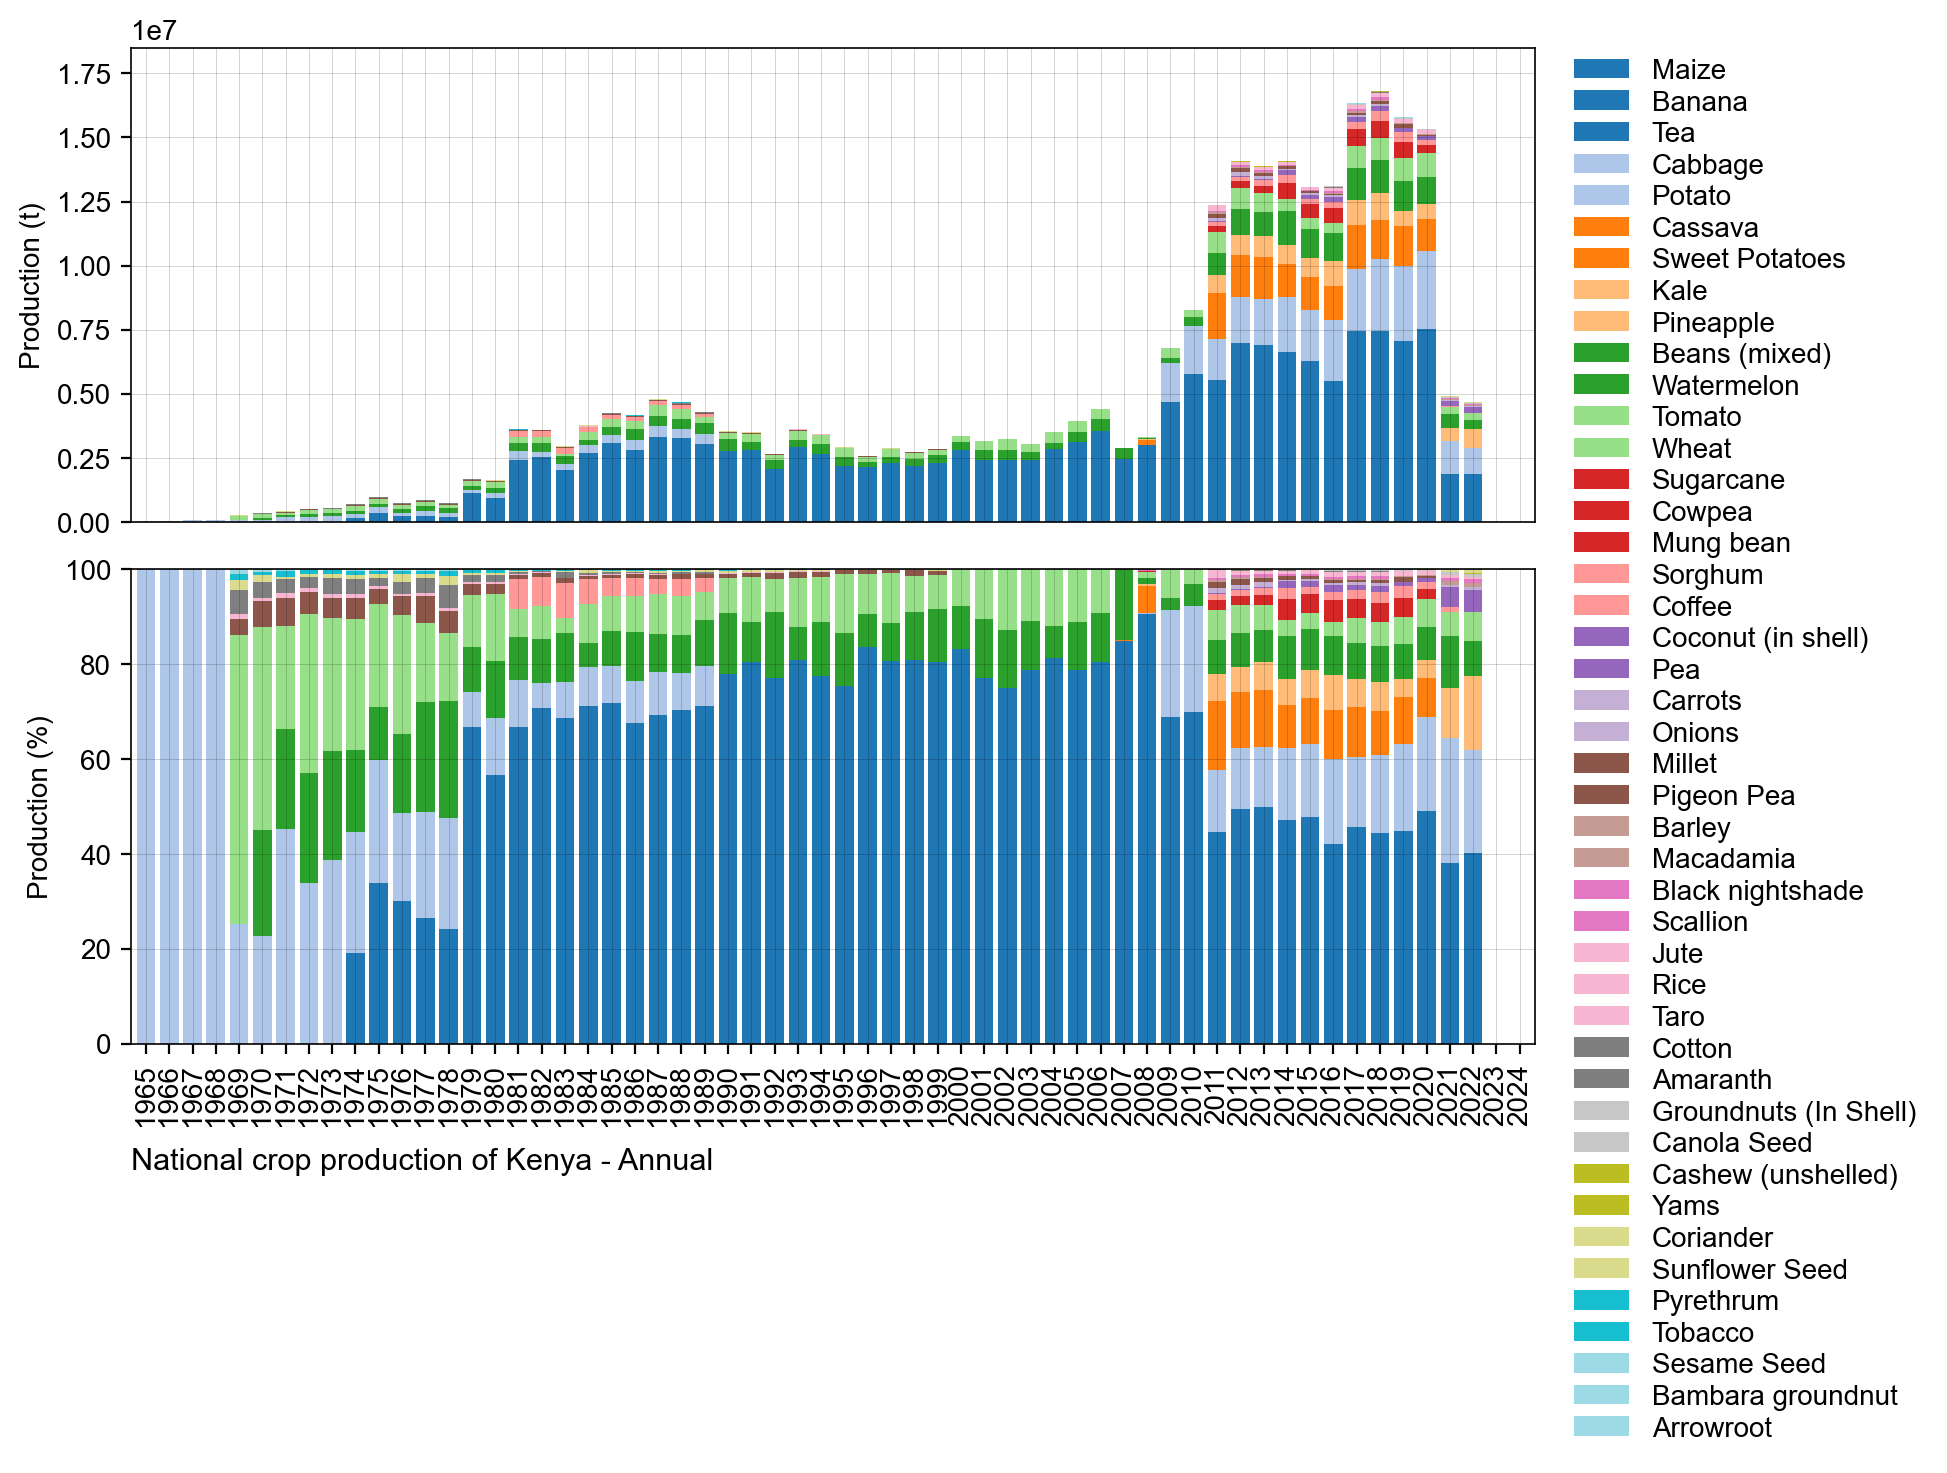

../figures/KE_bar_natgrainprod_Annual.png is saved.


/Users/dlee/harveststat-africa/notebook/tools_graphic.py:135: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  axes[1].grid(which='minor', axis='x', linestyle='-', color='black', visible=False)


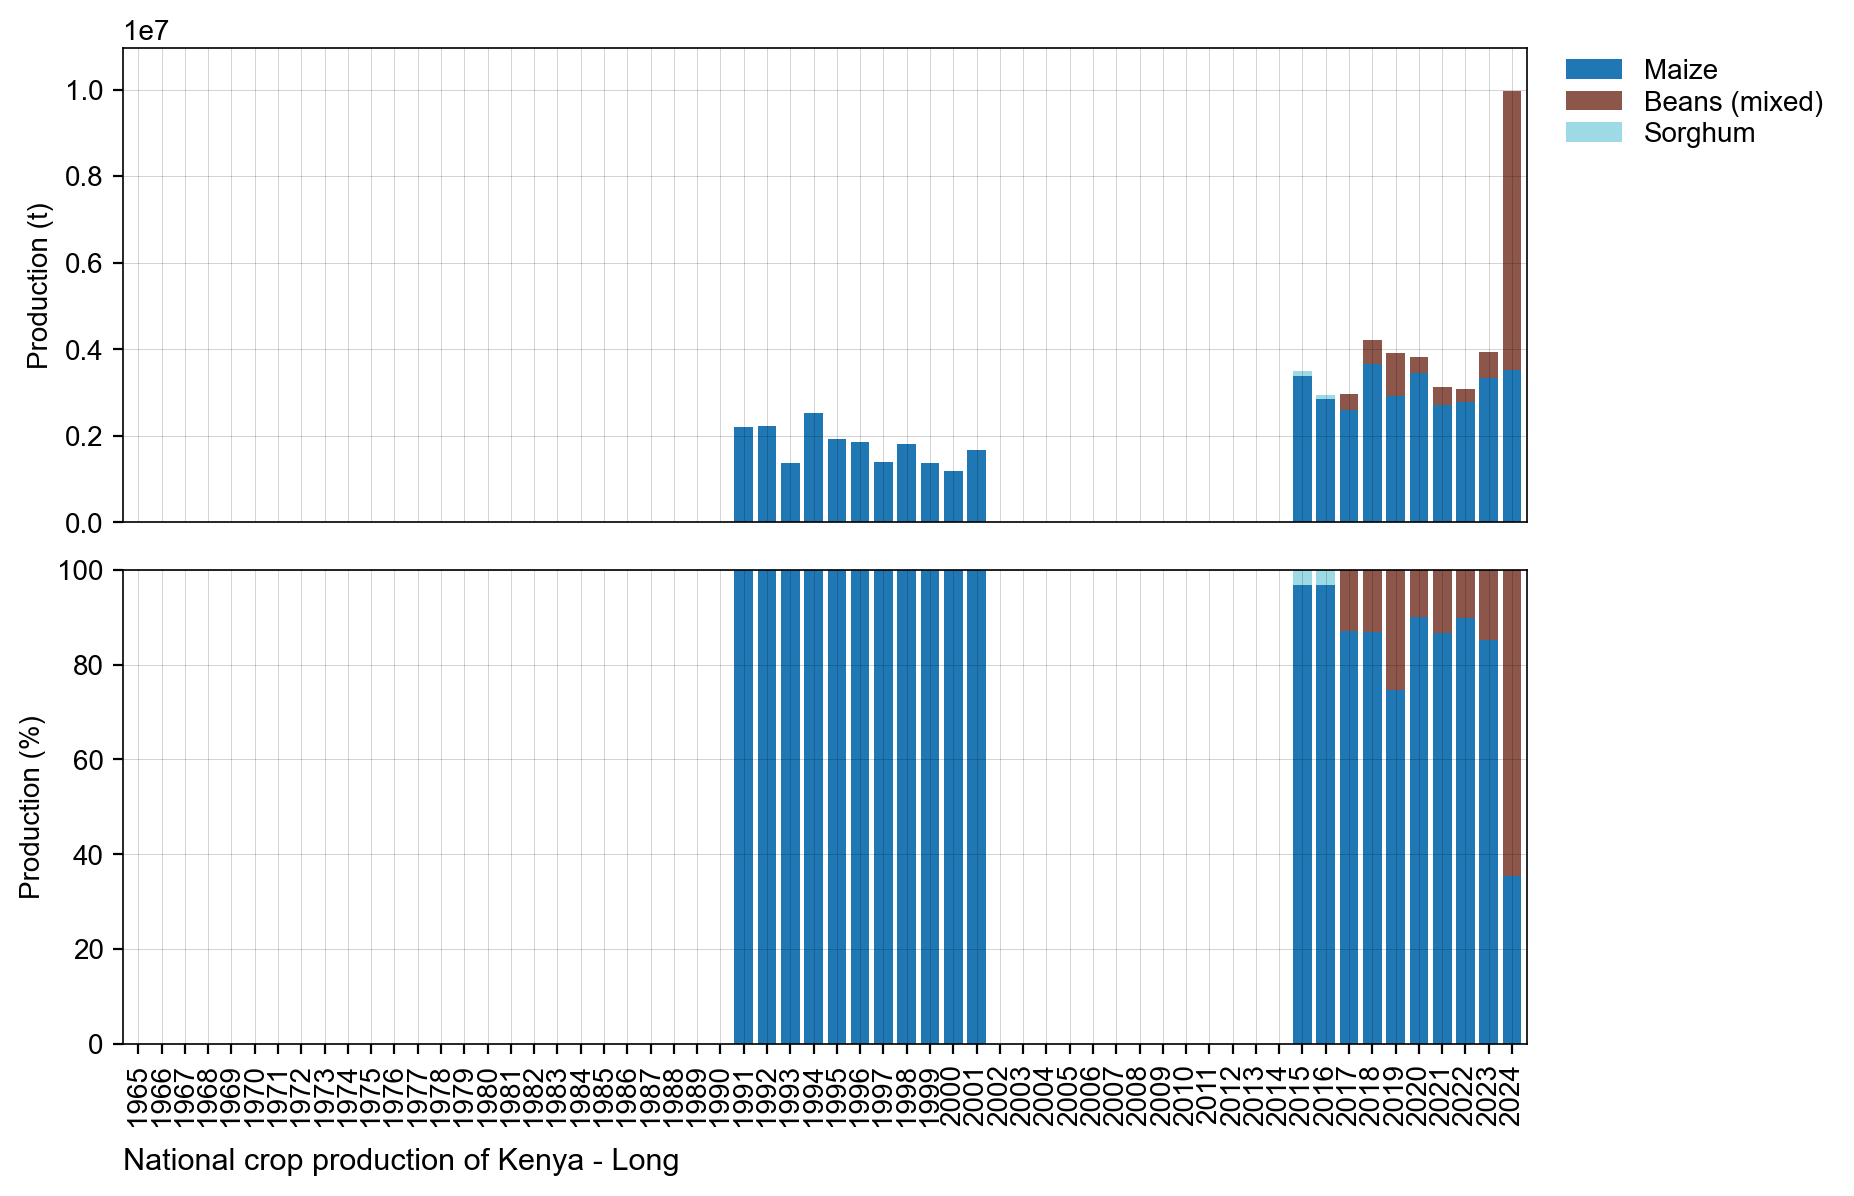

../figures/KE_bar_natgrainprod_Long.png is saved.


/Users/dlee/harveststat-africa/notebook/tools_graphic.py:135: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  axes[1].grid(which='minor', axis='x', linestyle='-', color='black', visible=False)


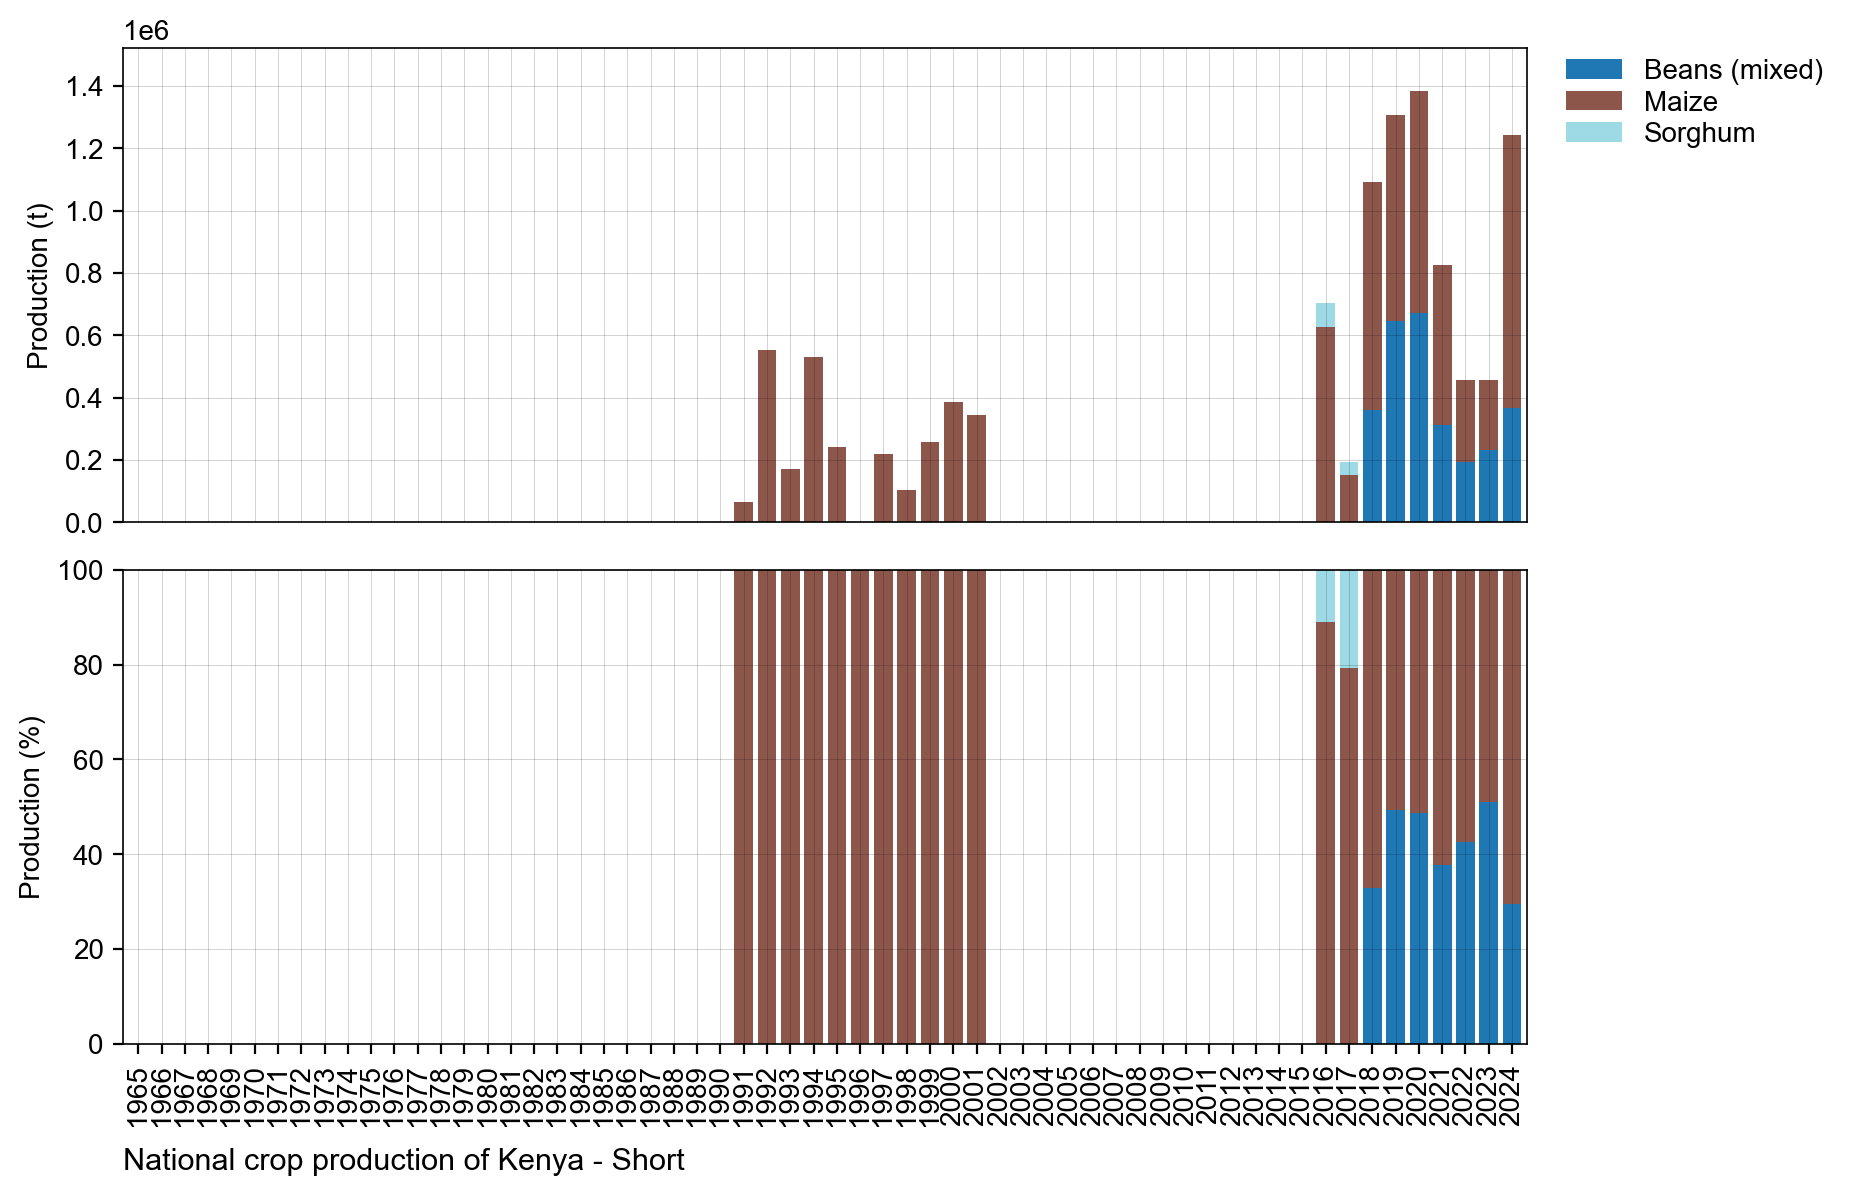

../figures/KE_bar_natgrainprod_Short.png is saved.


In [9]:
# Bar chart of national crop production
country_iso, country_name = 'KE', 'Kenya'
df = pd.read_csv('../data/crop/adm_crop_production_%s.csv' % country_iso, index_col=0)
df['year'] = df['harvest_year']
year = [df['year'].min(), df['year'].max()]
for season_name in ['Annual','Long','Short']:
    footnote = 'National crop production of %s - %s' % (country_name, season_name)
    fn_save = '../figures/%s_bar_natgrainprod_%s.png' % (country_iso, season_name)
    sub = df[df['season_name'] == season_name]
    PlotBarProduction(sub, year, footnote, fn_save)

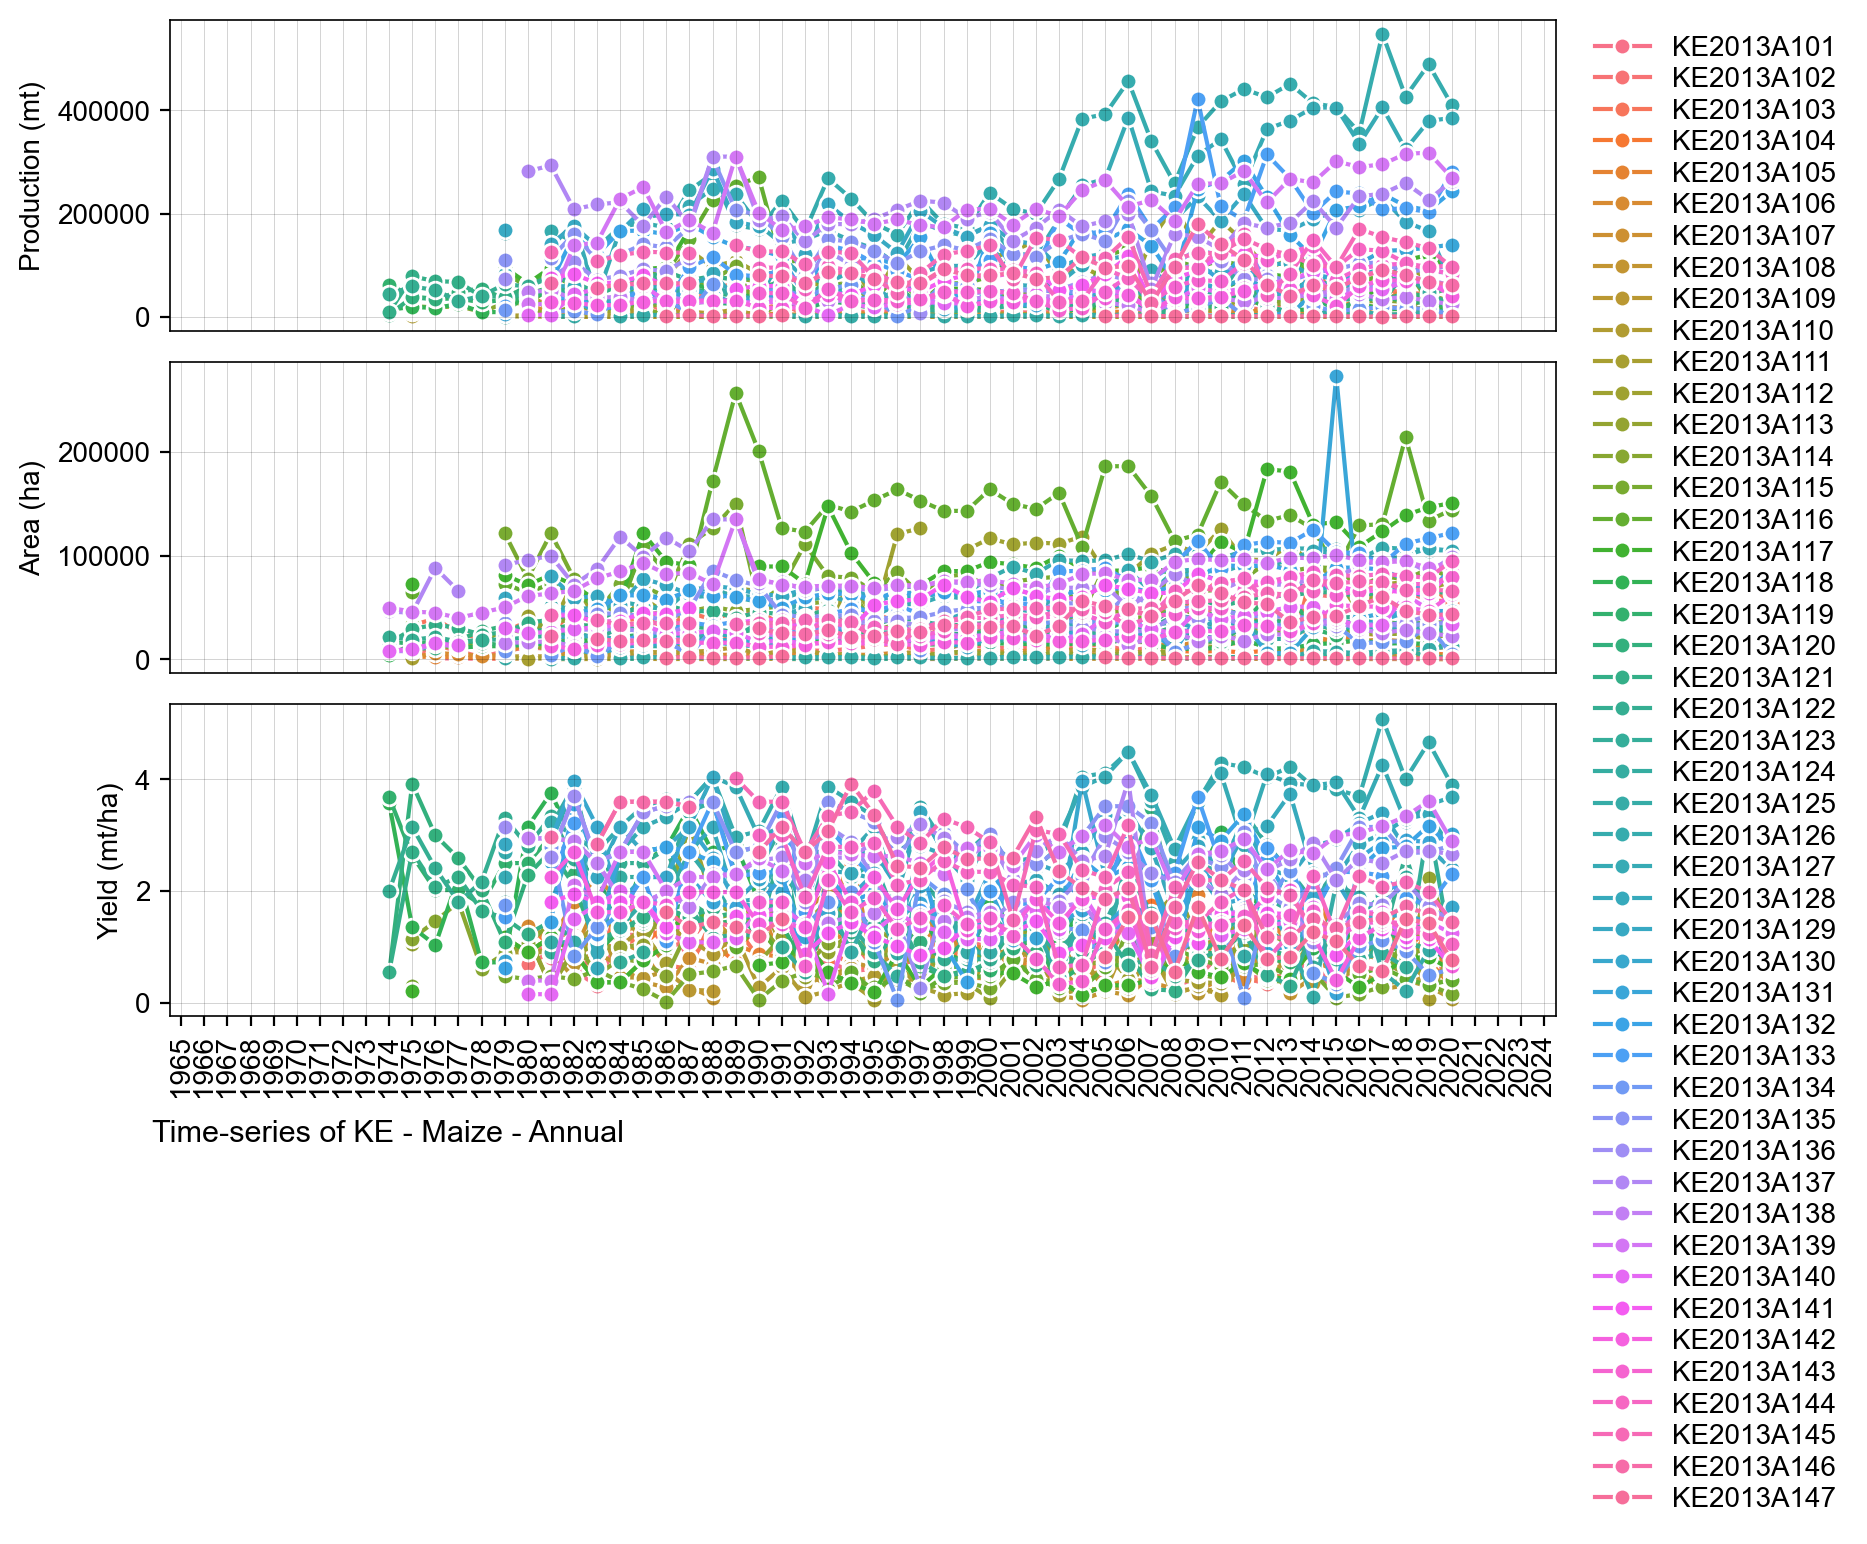

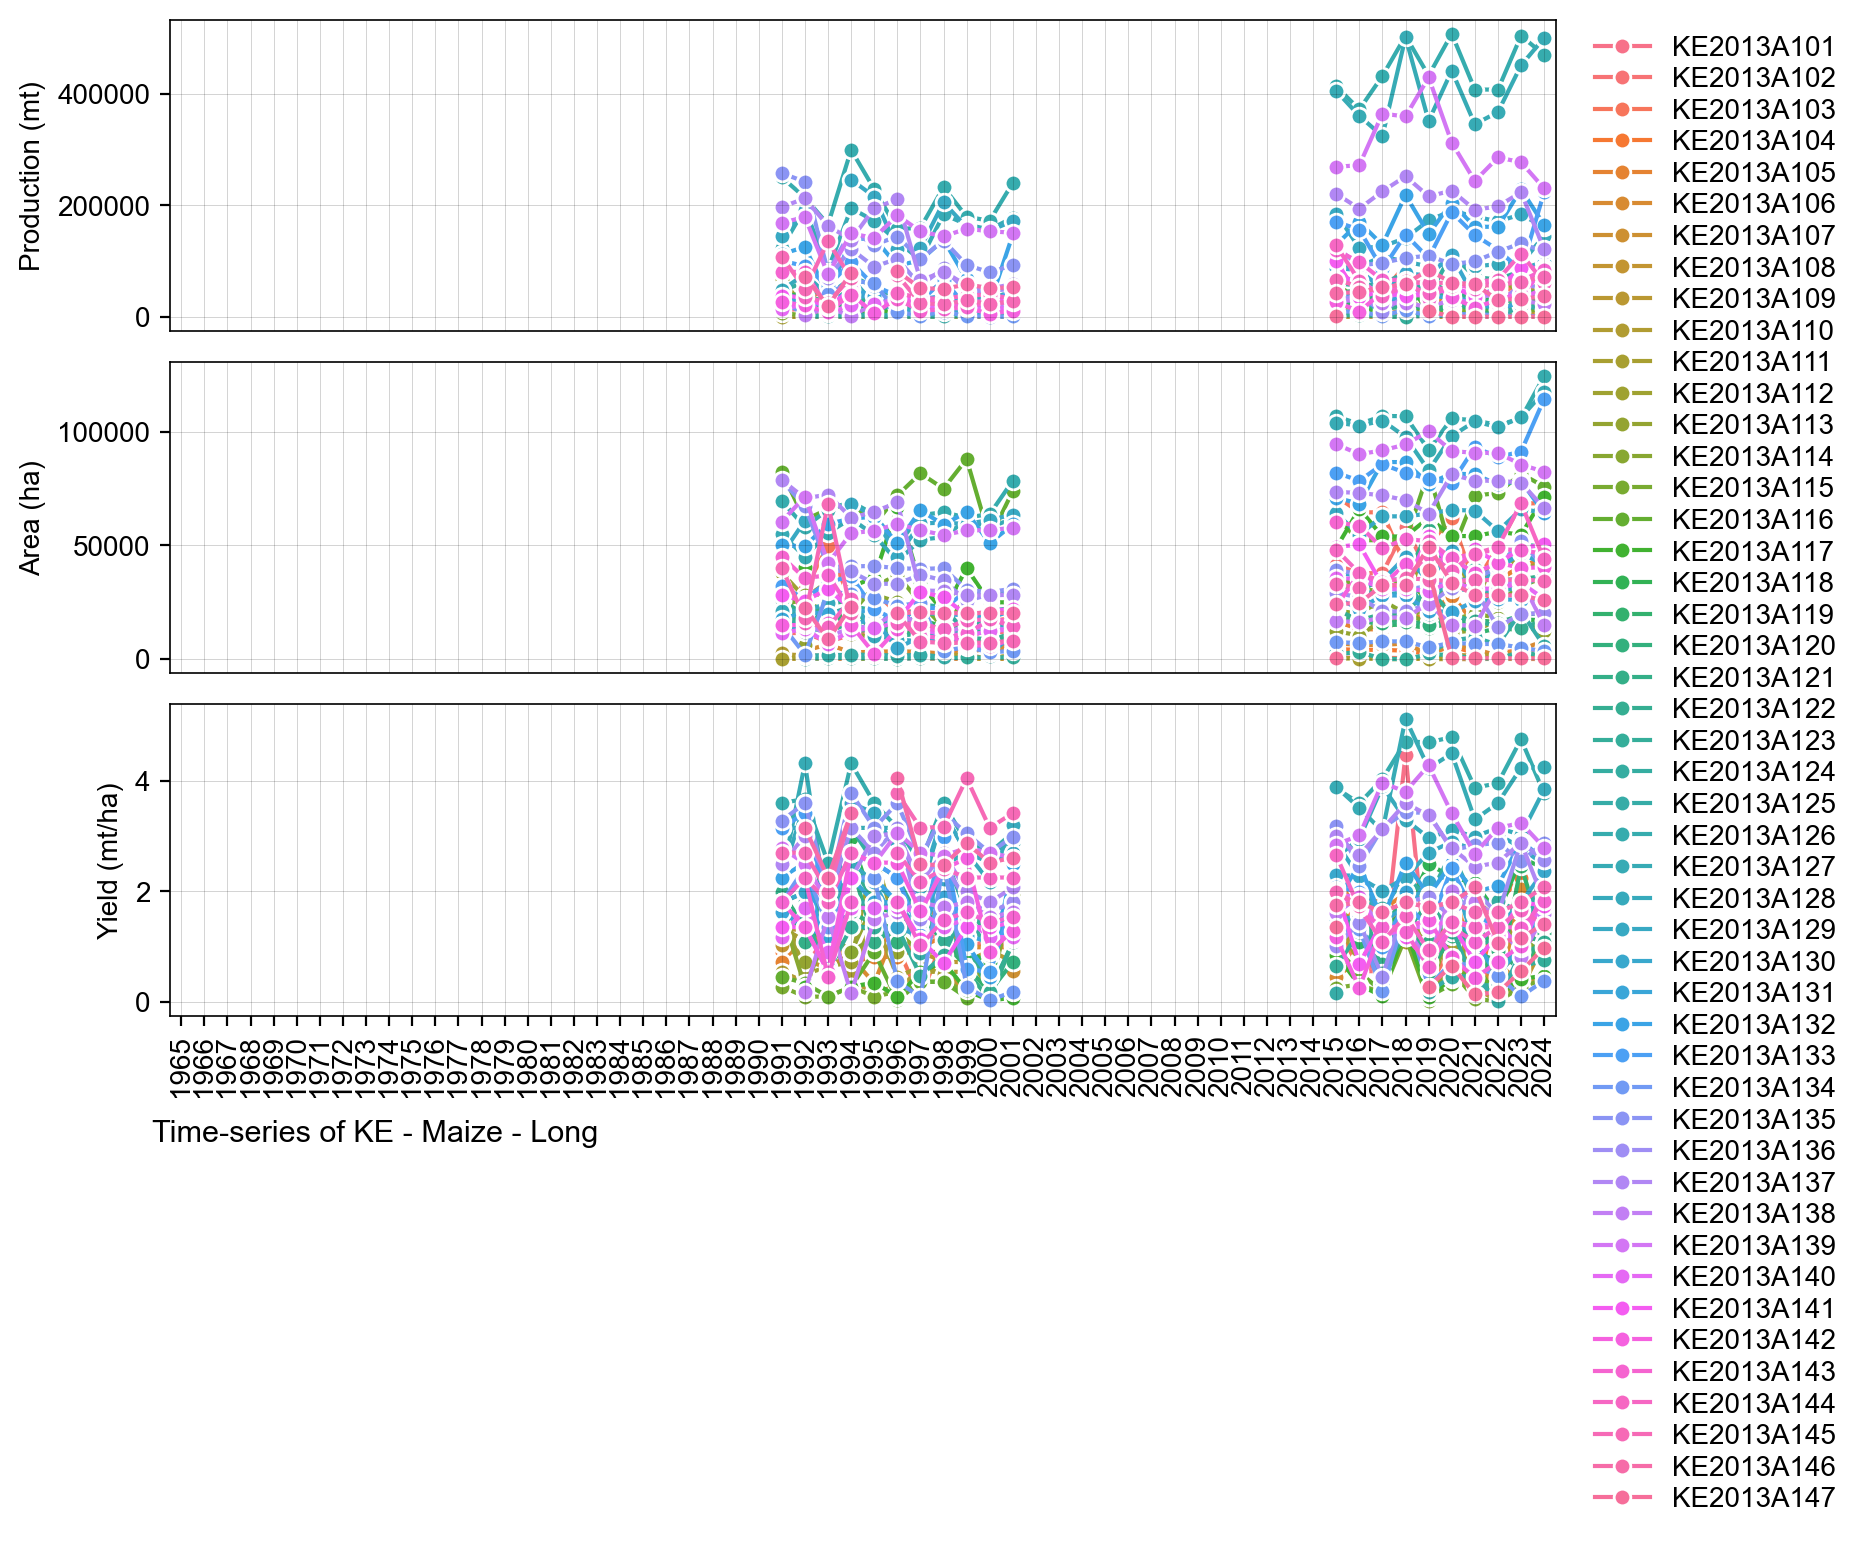

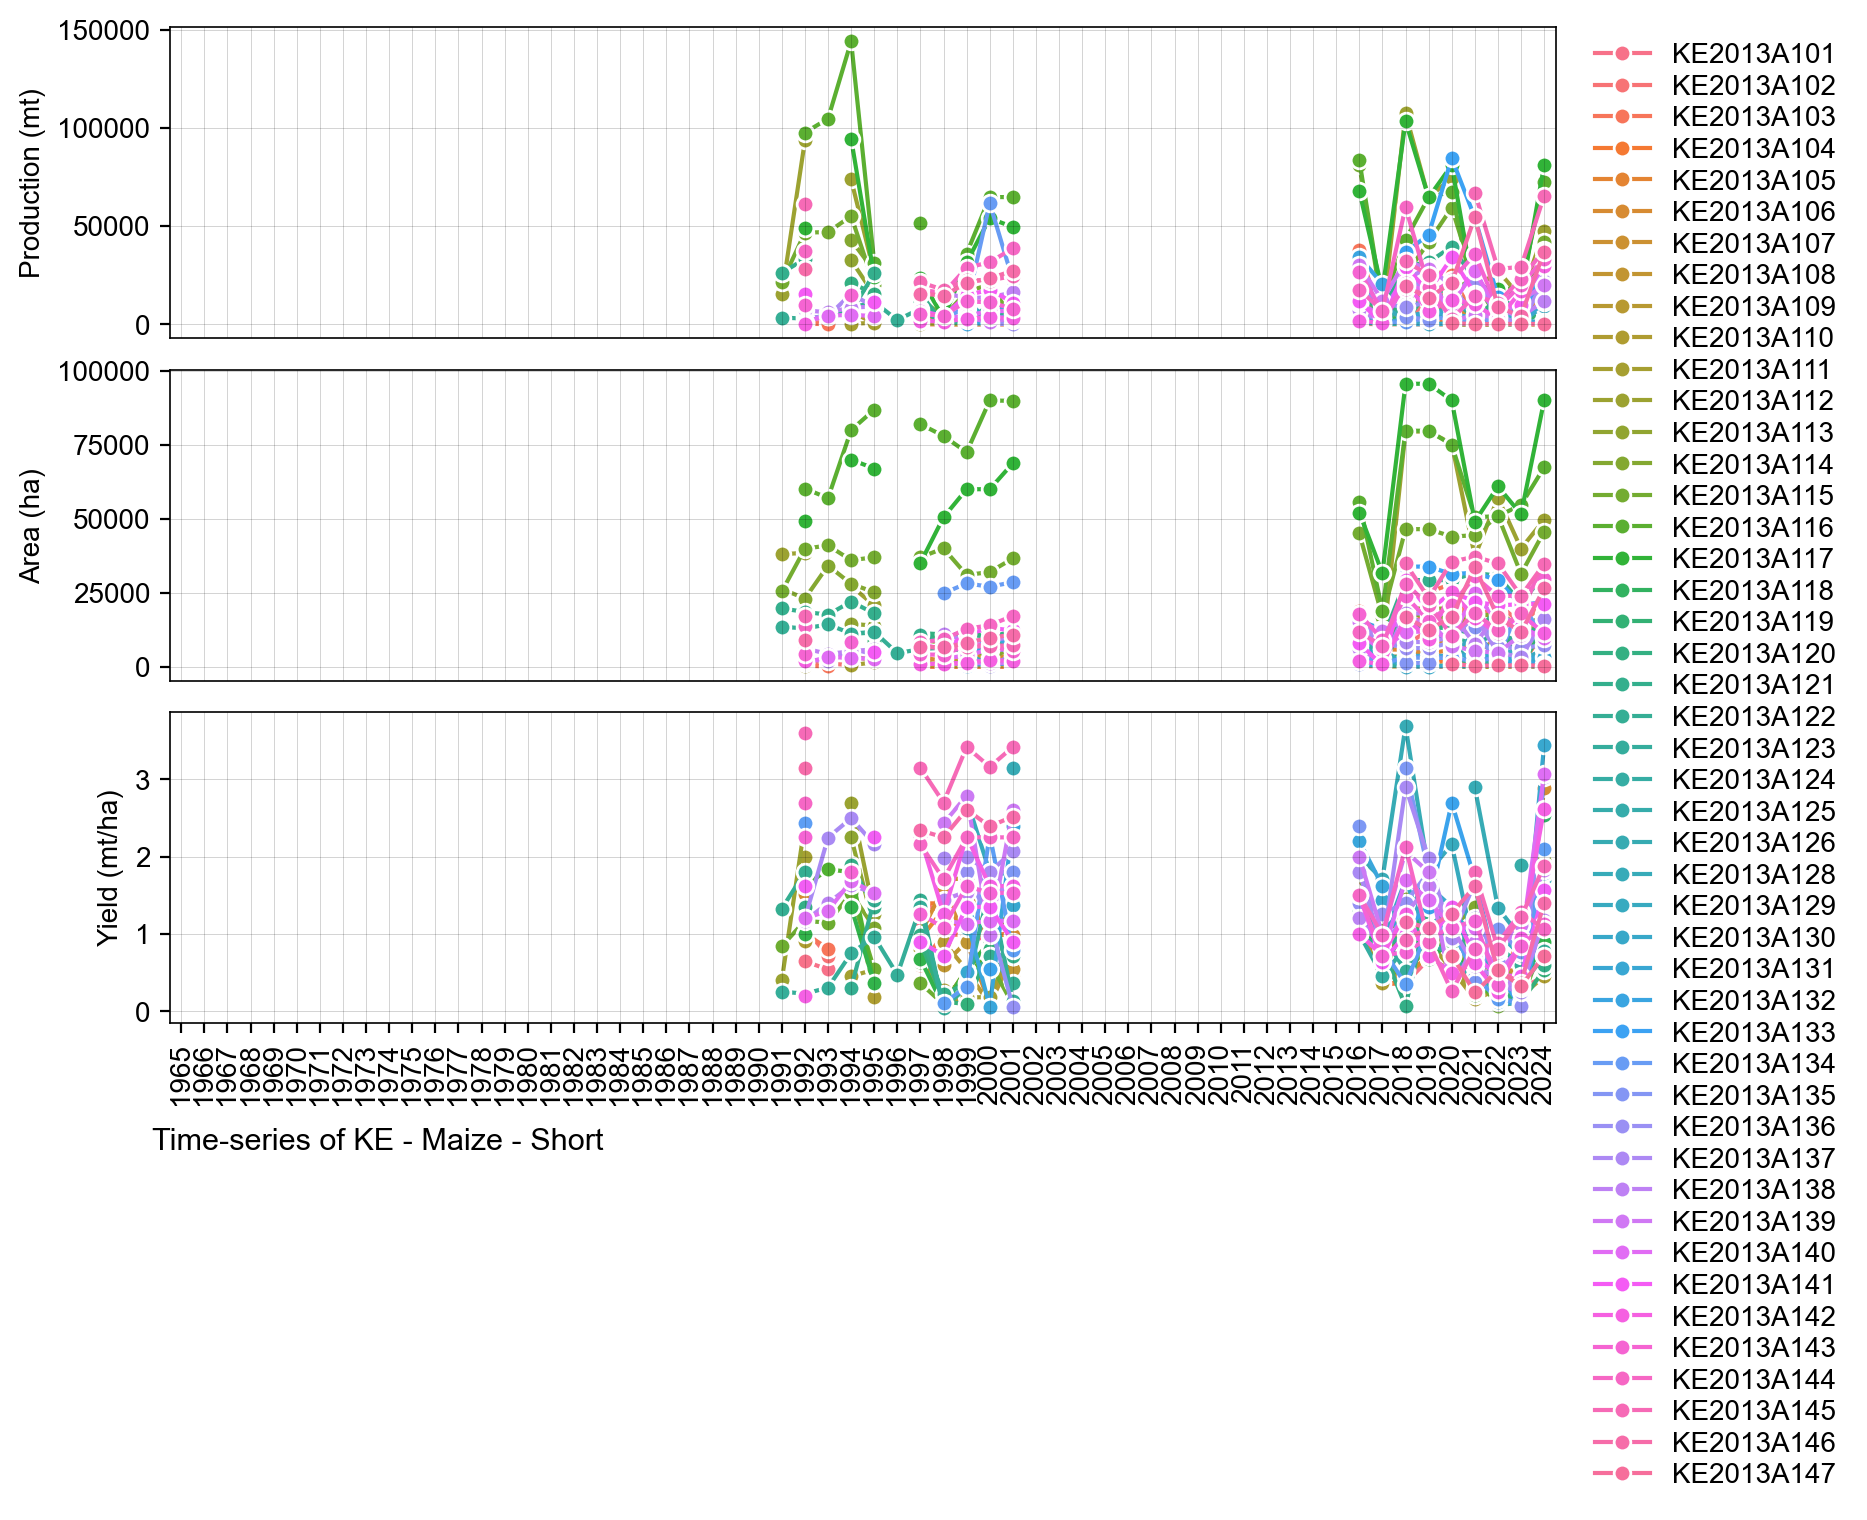

In [10]:
# Lineplot of Production-Area-Yield time-series
country_iso, country_name = 'KE', 'Kenya'
df = pd.read_csv('../data/crop/adm_crop_production_%s.csv' % country_iso, index_col=0)
df['year'] = df['harvest_year']
year = [df['year'].min(), df['year'].max()]
product_season = [
    ['Maize','Annual'],
    ['Maize','Long'],
    ['Maize','Short']
]
for product_name, season_name in product_season:
    footnote = 'Time-series of %s - %s - %s' % (country_iso, product_name, season_name)
    fn_save = '../figures/%s_line_pay_%s_%s.png' % (country_iso, product_name, season_name)
    sub = df[(df['product'] == product_name) & (df['season_name'] == season_name)]
    PlotLinePAY(sub, year, footnote)